## Fuente del dataset
Kaggle: https://www.kaggle.com/datasets/middlelight/goodreadsbookswithgenres

Contiene 13 columnas y 11127 registros de libros.

## Explicación de las columnas del dataset:
Book ID: Número único para identificar al libro.

Title: El nombre bajo el cual se publicó el libro.

Author: Nombres de los autores del libro.

Average Rating:  La calificación promedio total que recibió el libro.

ISBN: Otro número único para identificar el libro (Número Internacional Normalizado del Libro)

ISBN 13: Un ISBN de 13 dígitos para identificar el libro, en lugar del ISBN estándar de 11 dígitos.

Language code: Indica el idioma principal del libro. Por ejemplo, "eng" es el código estándar para el inglés.


Num pages: Número de páginas que contiene el libro.

Ratings count: Número total de calificaciones que recibió el libro.

Text reviews count: Número total de reseñas escritas que recibió el libro.

Publication date: Fecha en la que se publicó el libro por primera vez.

Publisher: Editorial que publicó el libro.

Genres: Género del libro.


In [15]:
pip install pandas matplotlib seaborn scipy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd

df = pd.read_csv('/workspaces/ProyectoFinal-DataAnalysisconPython/data/Goodreads.csv', on_bad_lines='skip')

print(f"Filas del dataset previo a la limpieza: {df.shape[0]}")
print(f"Columnas del dataset previo a la limpieza: {df.shape[1]}")

Filas del dataset previo a la limpieza: 11127
Columnas del dataset previo a la limpieza: 13


In [17]:
df['genres'].isna().sum()

np.int64(97)

In [18]:

df_limpio = (
    df.copy()
    .drop_duplicates()
    .dropna(how='all')
)

df_limpio.columns = df_limpio.columns.str.strip()

df_limpio['publication_date'] = pd.to_datetime(df_limpio['publication_date'], errors='coerce')
df_limpio = df_limpio.dropna(subset=['publication_date'])
df_limpio = df_limpio[df_limpio['num_pages'] > 0]

df_limpio['publication_year'] = df_limpio['publication_date'].dt.year.astype(int)
df_limpio['book_age_years'] = 2026 - df_limpio['publication_year']


df_limpio['genres'] = df_limpio['genres'].fillna('Unknown')

# DataFrame limpio a CSV
path_clean = '/workspaces/ProyectoFinal-DataAnalysisconPython/data/Goodreads_limpio.csv'
df_limpio.to_csv(path_clean, index=False, encoding='utf-8')

In [19]:
df_limpio.columns

Index(['Book Id', 'Title', 'Author', 'average_rating', 'isbn', 'isbn13',
       'language_code', 'num_pages', 'ratings_count', 'text_reviews_count',
       'publication_date', 'publisher', 'genres', 'publication_year',
       'book_age_years'],
      dtype='str')

In [20]:
df_limpio['publication_year'].sort_values(ascending=False)

9668     2020
10827    2019
1070     2019
390      2019
10339    2019
         ... 
437      1921
435      1919
6819     1914
6491     1913
9375     1900
Name: publication_year, Length: 11049, dtype: int64

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## Análisis exploratorio

## ¿Qué notas suelen tener los libros en Goodreads?
En Goodreads la gente casi nunca califica con notas muy bajas. Por ende, si un libro tiene un average_rating de 3.8, no es un "excelente" libro, es simplemente promedio. Si la editorial busca publicar libros realmente destacados, **el filtro debería estar por encima de 4.1 o 4.2 estrellas**.

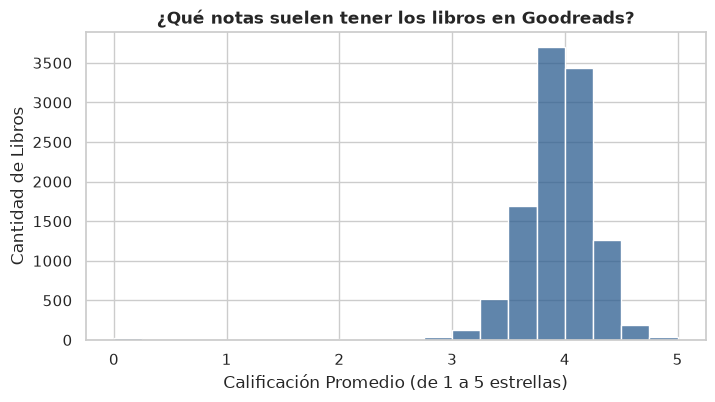

In [22]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

#nota promedio
sns.histplot(df_limpio['average_rating'], bins=20, color='#2b5c8f')

plt.title('¿Qué notas suelen tener los libros en Goodreads?', fontsize=12, fontweight='bold')
plt.xlabel('Calificación Promedio (de 1 a 5 estrellas)')
plt.ylabel('Cantidad de Libros')
plt.show()

## ¿Cuántas evaluaciones tienen los libros típicamente en Goodreads?

La barra más alta está casi pegada al cero. Esto significa que la enorme mayoría de los libros en el catálogo junta muy pocas evaluaciones (menos de 1.000 o 2.000).
La "cola larga" hacia la derecha: A medida que sube la cantidad de evaluaciones, la cantidad de libros cae drásticamente.

El éxito masivo es una excepción, no la regla.

**Un libro con 10.000 o 20.000 evaluaciones ya es un éxito comercial destacado dentro de la plataforma.**

No podemos medir el éxito usando promedios simples, porque un par de bestsellers sesgan todo. Es mejor usar medianas o definir el éxito como estar en el "Top 20%" con más interacciones.

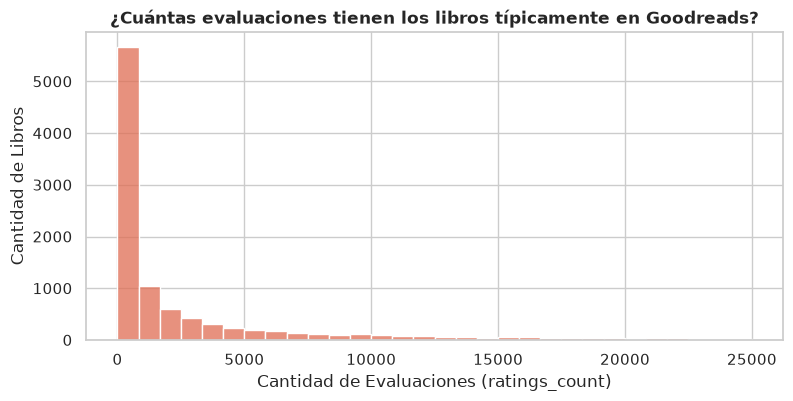

In [23]:
plt.figure(figsize=(9, 4))

# Filtramos solo hasta el percentil 90 para ver el comportamiento "normal"
# sin que los mega-bestsellers distorsionen la imagen
limite_90 = df_limpio['ratings_count'].quantile(0.90)
df_normales = df_limpio[df_limpio['ratings_count'] <= limite_90]

sns.histplot(df_normales['ratings_count'], bins=30, color='#e06d53')

plt.title('¿Cuántas evaluaciones tienen los libros típicamente en Goodreads?', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Evaluaciones (ratings_count)')
plt.ylabel('Cantidad de Libros')
plt.show()

## Matriz Estratégica de Perfiles de Catálogo

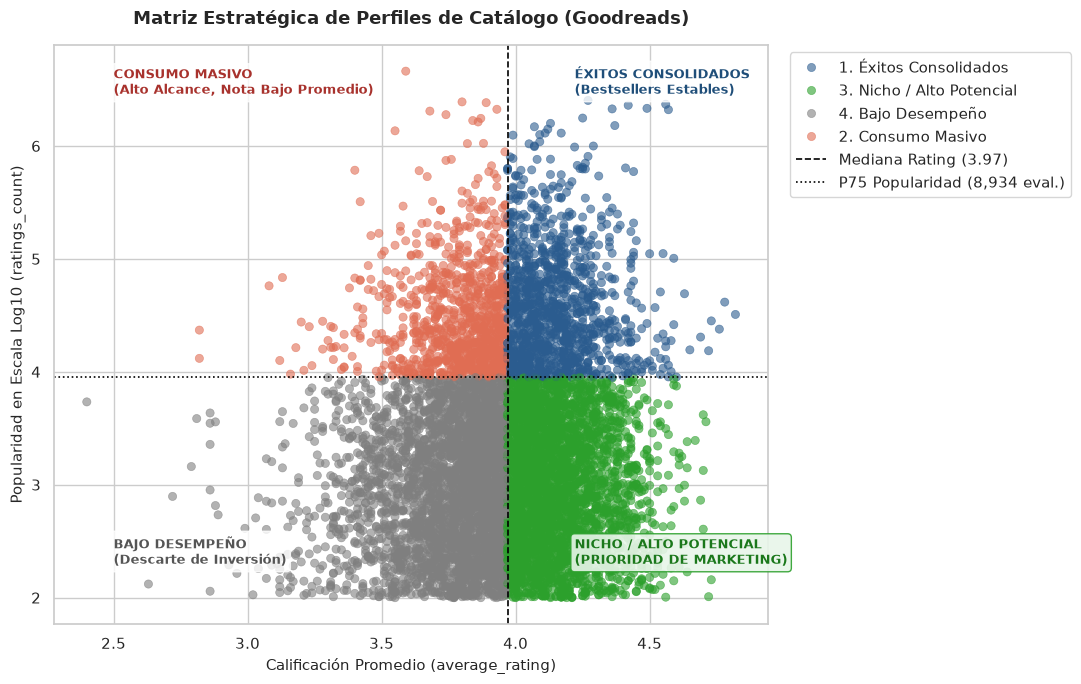

CARACTERÍSTICAS PROMEDIO DE CADA CUADRANTE
             perfil_libro  total_libros  promedio_paginas  mediana_paginas  promedio_rating  mediana_evaluaciones  compromiso_escrito_promedio_pct
   1. Éxitos Consolidados          1161        400.402239            352.0         4.154798               30401.0                         3.487116
        2. Consumo Masivo           935        358.009626            340.0         3.775444               23527.0                         4.540073
3. Nicho / Alto Potencial          3049        379.331256            320.0         4.163549                 932.0                         6.863903
        4. Bajo Desempeño          3239        305.756715            288.0         3.737339                 898.0                         8.180152


In [24]:

# 1. PREPARACIÓN DE DATOS Y UMBRALES
# Usamos un filtro mínimo de 100 evaluaciones para limpiar ruido
df_cuadrante = df_limpio[df_limpio['ratings_count'] >= 100].copy()

# Umbrales
umbral_rating = df_cuadrante['average_rating'].median()
umbral_popularity = df_cuadrante['ratings_count'].quantile(0.75)

# Transformación logarítmica de la popularidad para visualización clara
df_cuadrante['log_ratings_count'] = np.log10(df_cuadrante['ratings_count'])
log_umbral_popularity = np.log10(umbral_popularity)

# 2. ASIGNACIÓN DE PERFILES
condiciones = [
    (df_cuadrante['average_rating'] >= umbral_rating) & (df_cuadrante['ratings_count'] >= umbral_popularity),
    (df_cuadrante['average_rating'] < umbral_rating)  & (df_cuadrante['ratings_count'] >= umbral_popularity),
    (df_cuadrante['average_rating'] >= umbral_rating) & (df_cuadrante['ratings_count'] < umbral_popularity),
    (df_cuadrante['average_rating'] < umbral_rating)  & (df_cuadrante['ratings_count'] < umbral_popularity)
]

colores_perfil = {
    '1. Éxitos Consolidados': '#2b5c8f',    # Azul oscuro
    '2. Consumo Masivo': '#e06d53',         # Naranja/Rojo
    '3. Nicho / Alto Potencial': '#2ca02c', # Verde (Objetivo Marketing)
    '4. Bajo Desempeño': '#7f7f7f'         # Gris
}

etiquetas = list(colores_perfil.keys())
df_cuadrante['perfil'] = np.select(condiciones, etiquetas, default='Otro')

# 3. GENERACIÓN DEL GRÁFICO
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

# Plot de dispersión
sns.scatterplot(
    data=df_cuadrante,
    x='average_rating',
    y='log_ratings_count',
    hue='perfil',
    palette=colores_perfil,
    alpha=0.6,
    s=35,
    edgecolor=None
)

# LÍNEAS DIVISORIAS DE CUADRANTE
plt.axvline(x=umbral_rating, color='black', linestyle='--', linewidth=1.2, label=f'Mediana Rating ({umbral_rating:.2f})')
plt.axhline(y=log_umbral_popularity, color='black', linestyle=':', linewidth=1.2, label=f'P75 Popularidad ({int(umbral_popularity):,} eval.)')

# ANOTACIONES EN CADA CUADRANTE
# Cuadrante Superior Izquierdo: Consumo Masivo
plt.text(df_cuadrante['average_rating'].min() + 0.1, df_cuadrante['log_ratings_count'].max() - 0.2, 
         'CONSUMO MASIVO\n(Alto Alcance, Nota Bajo Promedio)', fontsize=9, fontweight='bold', color='#a8322d', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Cuadrante Superior Derecho: Éxitos Consolidados
plt.text(df_cuadrante['average_rating'].max() - 0.6, df_cuadrante['log_ratings_count'].max() - 0.2, 
         'ÉXITOS CONSOLIDADOS\n(Bestsellers Estables)', fontsize=9, fontweight='bold', color='#1f4e79', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Cuadrante Inferior Izquierdo: Bajo Desempeño
plt.text(df_cuadrante['average_rating'].min() + 0.1, df_cuadrante['log_ratings_count'].min() + 0.3, 
         'BAJO DESEMPEÑO\n(Descarte de Inversión)', fontsize=9, fontweight='bold', color='#555555', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Cuadrante Inferior Derecho: Nicho / Alto Potencial (PRIORIDAD)
plt.text(df_cuadrante['average_rating'].max() - 0.6, df_cuadrante['log_ratings_count'].min() + 0.3, 
         'NICHO / ALTO POTENCIAL\n(PRIORIDAD DE MARKETING)', fontsize=9, fontweight='bold', color='#1b781b', bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f5e9', edgecolor='#2ca02c', alpha=0.9))

# FORMATO Y TÍTULOS
plt.title('Matriz Estratégica de Perfiles de Catálogo (Goodreads)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Calificación Promedio (average_rating)', fontsize=11)
plt.ylabel('Popularidad en Escala Log10 (ratings_count)', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

# 1. Asegurar la clasificación en los 4 cuadrantes
df_limpio = df_limpio[df_limpio['ratings_count'] >= 100].copy()

umbral_rating = df_limpio['average_rating'].median()
umbral_popularity = df_limpio['ratings_count'].quantile(0.75)

condiciones = [
    (df_limpio['average_rating'] >= umbral_rating) & (df_limpio['ratings_count'] >= umbral_popularity),
    (df_limpio['average_rating'] < umbral_rating)  & (df_limpio['ratings_count'] >= umbral_popularity),
    (df_limpio['average_rating'] >= umbral_rating) & (df_limpio['ratings_count'] < umbral_popularity),
    (df_limpio['average_rating'] < umbral_rating)  & (df_limpio['ratings_count'] < umbral_popularity)
]

etiquetas = ['1. Éxitos Consolidados', '2. Consumo Masivo', '3. Nicho / Alto Potencial', '4. Bajo Desempeño']
df_limpio['perfil_libro'] = np.select(condiciones, etiquetas, default='Sin Clasificar')

# Métrica de compromiso escrito
df_limpio['engagement_rate_pct'] = (df_limpio['text_reviews_count'] / df_limpio['ratings_count']) * 100

# 2. TABLA COMPARATIVA DE CARACTERÍSTICAS
resumen_caracteristicas = df_limpio.groupby('perfil_libro').agg(
    total_libros=('Book Id', 'count'),
    promedio_paginas=('num_pages', 'mean'),
    mediana_paginas=('num_pages', 'median'),
    promedio_rating=('average_rating', 'mean'),
    mediana_evaluaciones=('ratings_count', 'median'),
    compromiso_escrito_promedio_pct=('engagement_rate_pct', 'mean')
).reset_index()

print("CARACTERÍSTICAS PROMEDIO DE CADA CUADRANTE")
print(resumen_caracteristicas.to_string(index=False))

## Top 10 géneros con mayor cantidad de libros exitosos

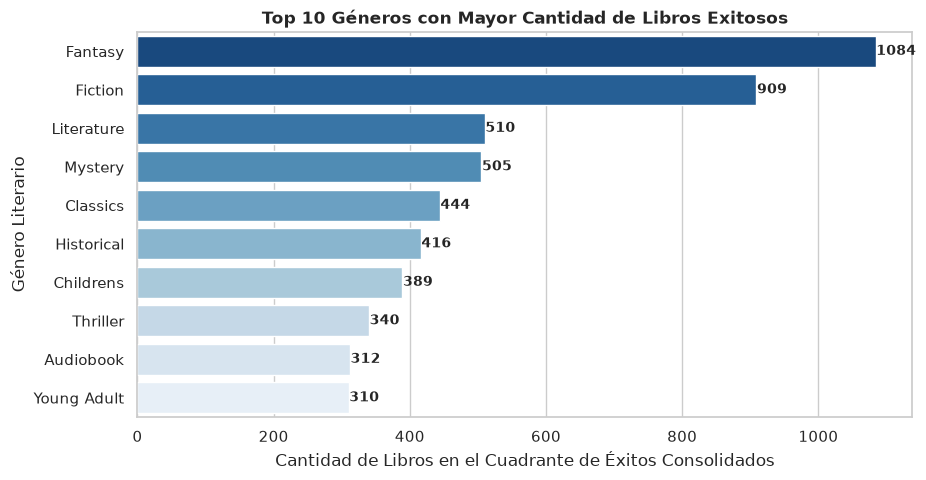

In [33]:
# Nos quedamos con los libros en el perfil de Éxitos consolidados
df_limpio = df_limpio[df_limpio['ratings_count'] >= 100].copy()

umbral_rating = df_limpio['average_rating'].median()
umbral_popularity = df_limpio['ratings_count'].quantile(0.75)
alto_exito = df_limpio[(df_limpio['average_rating'] >= umbral_rating) & (df_limpio['ratings_count'] >= umbral_popularity)].copy()

# Desanidamos la columna 'genres' (separar por comas y punto y comas)
alto_exito['genres_clean'] = alto_exito['genres'].fillna('Unknown')
generos_separados = alto_exito.assign(genero=alto_exito['genres_clean'].str.split(r'[,;]')).explode('genero')
generos_separados['genero'] = generos_separados['genero'].str.strip()

# Contamos el Top 10 de géneros más frecuentes
top10_generos = generos_separados['genero'].value_counts().head(10)

# Graficamos
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top10_generos.values, 
    y=top10_generos.index, 
    hue=top10_generos.index,
    palette='Blues_r',
    legend=False
)

plt.title('Top 10 Géneros con Mayor Cantidad de Libros Exitosos', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Libros en el Cuadrante de Éxitos Consolidados')
plt.ylabel('Género Literario')

# Agregamos los números exactos al final de cada barra
for index, value in enumerate(top10_generos.values):
    plt.text(value + 1, index, str(value), va='center', fontsize=10, fontweight='bold')

plt.show()

## Extensión del libro
Buscamos corroborar la hipotésis de que los libros de extensión media a larga (300 a 500 páginas) tienen una probabilidad significativamente mayor de pertenecer al perfil de *Alto Potencial* o *Éxitos Consolidados* que los libros de menos de 200 páginas.

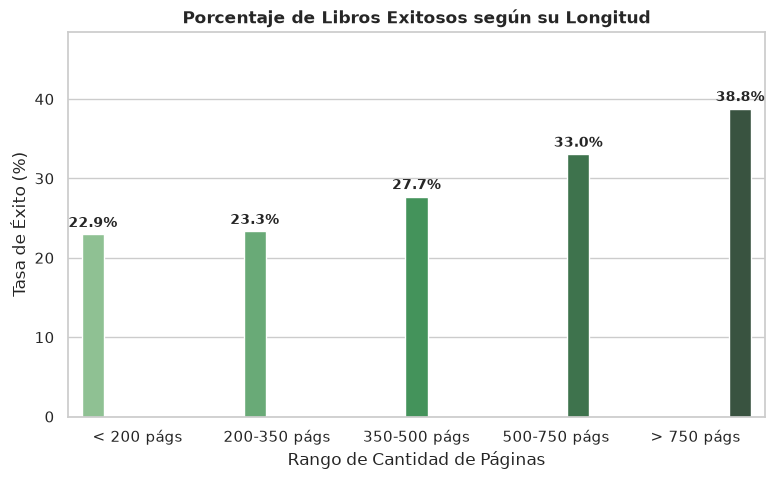

In [32]:
df_paginas = df_limpio[
    (df_limpio["num_pages"] >= 10)
    & (df_limpio["num_pages"] <= 1500)
    & (df_limpio["ratings_count"] >= 100)
].copy()


median_rating = df_paginas["average_rating"].median()
p50_ratings = df_paginas["ratings_count"].median()

df_paginas["es_exito"] = (
    (df_paginas["average_rating"] >= median_rating)
    & (df_paginas["ratings_count"] >= p50_ratings)
).astype(int)

labels_rangos = ['< 200 págs', '200-350 págs', '350-500 págs', '500-750 págs', '> 750 págs']
df_paginas['rango_paginas'] = pd.cut(
    df_paginas['num_pages'], 
    bins=[0, 200, 350, 500, 750, 2000], 
    labels=labels_rangos
)

# calcular la tasa/porcentaje de éxito por rango
tasa_exito = df_paginas.groupby('rango_paginas', observed=False)['es_exito'].mean() * 100

# graficar
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=tasa_exito.index, 
    y=tasa_exito.values, 
    hue=tasa_exito.index,
    palette='Greens_d',
    legend=False
    )

plt.title('Porcentaje de Libros Exitosos según su Longitud', fontsize=12, fontweight='bold')
plt.xlabel('Rango de Cantidad de Páginas')
plt.ylabel('Tasa de Éxito (%)')
plt.ylim(0, max(tasa_exito.values) * 1.25) # Margen para los números sobre las barras

# Agregar el valor exacto sobre cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                xytext=(0, 3), textcoords='offset points')

plt.show()

## Porcentaje de Libros Exitosos según su Longitud
**Zona Óptima**: La tasa de éxito es más baja en libros muy cortos (< 200 páginas) y tiende a subir en los rangos intermedios y largos (350 a 750 páginas).

Explicación del comportamiento del lector: Los libros demasiado cortos suelen percibirse como de menor valor o contenido incompleto, logrando menos tracción comercial masiva.

Los libros más extensos (350+ páginas) suelen pertenecer a géneros de gran lealtad (como Fantasía, Ciencia Ficción o Ficción Histórica), donde los lectores generan un compromiso mayor, dejan más calificaciones y puntúan con notas elevadas.

Recomendación para la Editorial:
 Si hay que elegir entre dos manuscritos prometedores para destinar presupuesto de marketing, un libro con una extensión sólida (300-500 páginas) suele ofrecer estadísticamente un rendimiento más seguro en plataformas de recomendación como Goodreads.

In [27]:
from scipy.stats import chi2_contingency

# 1. PREPARACIÓN DE DATOS Y FILTRADO INICIAL
# Excluimos registros sin páginas o con valores atípicos extremos
df_valido = df_limpio[(df_limpio['num_pages'] >= 10) & (df_limpio['num_pages'] <= 1500) & (df_limpio['ratings_count'] >= 100)].copy()

# 2. DEFINICIÓN DE LA VARIABLE OBJETIVO (ÉXITO)
# Definimos éxito como tener nota superior a la mediana y estar en el percentil 50+ de popularidad
median_rating = df_valido['average_rating'].median()
p50_ratings = df_valido['ratings_count'].median()

df_valido['es_exito'] = (
    (df_valido['average_rating'] >= median_rating) & 
    (df_valido['ratings_count'] >= p50_ratings)
).astype(int)

# 3. CREACIÓN DE INTERVALOS DE PÁGINAS (RANGOS)
bins = [0, 200, 350, 500, 750, 2000]
labels = ['< 200 págs (Corto)', '200-350 págs (Medio-Corto)', '350-500 págs (Medio-Largo)', '500-750 págs (Largo)', '> 750 págs (Muy Largo)']

df_valido['rango_paginas'] = pd.cut(df_valido['num_pages'], bins=bins, labels=labels)

# 4. TABLA DE FRECUENCIAS Y TASA DE ÉXITO POR RANGO
tabla_resumen = df_valido.groupby('rango_paginas', observed=False).agg(
    total_libros=('es_exito', 'count'),
    libros_exitosos=('es_exito', 'sum'),
    tasa_exito_pct=('es_exito', lambda x: round(x.mean() * 100, 2))
).reset_index()

print("TASA DE ÉXITO SEGÚN RANGO DE PÁGINAS")
print(tabla_resumen.to_string(index=False))
print("\n" + "-"*50 + "\n")

# 5. PRUEBA DE HIPÓTESIS ESTADÍSTICA (Chi-Cuadrado de Independencia)
# Construimos la tabla de contingencia
contingency_table = pd.crosstab(df_valido['rango_paginas'], df_valido['es_exito'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("RESULTADOS DE LA PRUEBA ESTADÍSTICA (Chi-Cuadrado)")
print(f"Estadístico Chi2: {chi2:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"Grados de libertad: {dof}")

# 6. CONCLUSIÓN AUTOMÁTICA
alpha = 0.05
if p_value < alpha:
    print("\nCONCLUSIÓN: Se RECHAZA la hipótesis nula.")
    print("Existe una relación estadísticamente significativa entre la cantidad de páginas y la probabilidad de éxito de un libro.")
else:
    print("\nCONCLUSIÓN: No se rechaza la hipótesis nula.")
    print("No hay evidencia estadística suficiente para afirmar que la cantidad de páginas influya en el éxito.")

TASA DE ÉXITO SEGÚN RANGO DE PÁGINAS
             rango_paginas  total_libros  libros_exitosos  tasa_exito_pct
        < 200 págs (Corto)          1818              417           22.94
200-350 págs (Medio-Corto)          3092              721           23.32
350-500 págs (Medio-Largo)          2071              574           27.72
      500-750 págs (Largo)           923              305           33.04
    > 750 págs (Muy Largo)           415              161           38.80

--------------------------------------------------

RESULTADOS DE LA PRUEBA ESTADÍSTICA (Chi-Cuadrado)
Estadístico Chi2: 82.1987
p-value: 5.9574e-17
Grados de libertad: 4

CONCLUSIÓN: Se RECHAZA la hipótesis nula.
Existe una relación estadísticamente significativa entre la cantidad de páginas y la probabilidad de éxito de un libro.


## Desempeño del Libro vs Historial del Autor

In [ ]:
from scipy.stats import mannwhitneyu

# FILTRADO INICIAL Y DEFINICIÓN DE ÉXITO
df_limpio = df_limpio[(df_limpio['ratings_count'] >= 100)].copy()

# Definimos éxito: Nota >= mediana Y popularidad >= mediana
median_rating = df_limpio['average_rating'].median()
median_popularity = df_limpio['ratings_count'].median()

df_limpio['es_exito'] = (
    (df_limpio['average_rating'] >= median_rating) & 
    (df_limpio['ratings_count'] >= median_popularity)
).astype(int)

# CÁLCULO DEL HISTORIAL PREVIO DEL AUTOR (Excluyendo el libro actual)
# Para cada libro, calculamos el rating promedio de los OTROS libros del mismo autor
df_limpio['autor_otros_libros_count'] = 0
df_limpio['autor_rating_previo'] = np.nan
df_limpio['autor_popularity_previa'] = np.nan

# Agrupamos por autor para calcular métricas acumuladas fuera del libro actual
for autor, grupo in df_limpio.groupby('Author'):
    if len(grupo) > 1:
        for idx, row in grupo.iterrows():
            otros_libros = grupo.drop(idx)
            df_limpio.loc[idx, 'autor_otros_libros_count'] = len(otros_libros)
            df_limpio.loc[idx, 'autor_rating_previo'] = otros_libros['average_rating'].mean()
            df_limpio.loc[idx, 'autor_popularity_previa'] = otros_libros['ratings_count'].median()

# FILTRAR SOLO AUTORES CON MÁS DE 1 LIBRO EN EL DATASET
df_multilibro = df_limpio[df_limpio['autor_otros_libros_count'] > 0].copy()

# RESUMEN COMPARATIVO: ÉXITO VS NO ÉXITO
resumen_autor = df_multilibro.groupby('es_exito').agg(
    total_libros=('Book Id', 'count'),
    media_rating_previo_autor=('autor_rating_previo', 'mean'),
    mediana_popularidad_previa_autor=('autor_popularity_previa', 'median')
).reset_index()

resumen_autor['es_exito'] = resumen_autor['es_exito'].map({1: 'Alto Éxito', 0: 'Bajo/Medio Éxito'})

print("DESEMPEÑO DEL LIBRO VS HISTORIAL DEL AUTOR")
print(resumen_autor.to_string(index=False))
print("\n" + "-"*50 + "\n")

#PRUEBA DE HIPÓTESIS ESTADÍSTICA (Prueba U de Mann-Whitney)
# Compara las distribuciones del rating previo del autor entre libros exitosos y no exitosos
rating_exitosos = df_multilibro[df_multilibro['es_exito'] == 1]['autor_rating_previo']
rating_no_exitosos = df_multilibro[df_multilibro['es_exito'] == 0]['autor_rating_previo']

stat, p_value = mannwhitneyu(rating_exitosos, rating_no_exitosos, alternative='greater')

print("RESULTADOS DE LA PRUEBA ESTADÍSTICA (Mann-Whitney U)")
print(f"Estadístico U: {stat:.2f}")
print(f"p-value: {p_value:.4e}")

#CONCLUSIÓN AUTOMÁTICA
if p_value < 0.05:
    print("\nCONCLUSIÓN: Se RECHAZA la hipótesis nula.")
    print("Los libros exitosos pertenecen a autores con antecedentes de calificaciones significativamente más altas en sus otras obras.")
else:
    print("\nCONCLUSIÓN: No se rechaza la hipótesis nula.")
    print("No hay evidencia suficiente para afirmar que la trayectoria previa del autor garantice el éxito del libro.")

DESEMPEÑO DEL LIBRO VS HISTORIAL DEL AUTOR
        es_exito  total_libros  media_rating_previo_autor  mediana_popularidad_previa_autor
Bajo/Medio Éxito          3291                   3.898758                            2807.0
      Alto Éxito          1371                   4.055242                            5757.5

--------------------------------------------------

RESULTADOS DE LA PRUEBA ESTADÍSTICA (Mann-Whitney U)
Estadístico U: 3233767.00
p-value: 6.6040e-121

CONCLUSIÓN: Se RECHAZA la hipótesis nula.
Los libros exitosos pertenecen a autores con antecedentes de calificaciones significativamente más altas en sus otras obras.


## Engagement Ratio

In [ ]:
from scipy.stats import mannwhitneyu, spearmanr

# Se requieren al menos 100 evaluaciones para evitar divisiones por valores casi nulos
df_valid = df[df['ratings_count'] >= 100].copy()

# CÁLCULO DE LA TASA DE COMPROMISO ESCRITO (Engagement Rate)
df_valid['review_engagement_rate'] = df_valid['text_reviews_count'] / df_valid['ratings_count']

# DEFINICIÓN DE ÉXITO (Éxitos Consolidados)
median_rating = df_valid['average_rating'].median()
median_popularity = df_valid['ratings_count'].median()

df_valid['es_exito'] = (
    (df_valid['average_rating'] >= median_rating) & 
    (df_valid['ratings_count'] >= median_popularity)
).astype(int)

#RESUMEN COMPARATIVO DE MÉTRICAS SEGÚN ÉXITO
resumen_engagement = df_valid.groupby('es_exito').agg(
    total_libros=('Book Id', 'count'),
    media_engagement_pct=('review_engagement_rate', lambda x: round(x.mean() * 100, 2)),
    mediana_engagement_pct=('review_engagement_rate', lambda x: round(x.median() * 100, 2)),
    media_average_rating=('average_rating', 'mean')
).reset_index()

resumen_engagement['es_exito'] = resumen_engagement['es_exito'].map({1: 'Alto Éxito', 0: 'Bajo/Medio Éxito'})

print("COMPROMISO ESCRITO SEGÚN PERFIL DEL LIBRO")
print(resumen_engagement.to_string(index=False))
print("\n" + "-"*50 + "\n")

# PRUEBAS ESTADÍSTICAS
engagement_exitosos = df_valid[df_valid['es_exito'] == 1]['review_engagement_rate']
engagement_no_exitosos = df_valid[df_valid['es_exito'] == 0]['review_engagement_rate']

# Prueba U de Mann-Whitney (Diferencia entre grupos)
stat_u, p_val_u = mannwhitneyu(engagement_exitosos, engagement_no_exitosos, alternative='greater')

# Correlación de Spearman entre Engagement y Éxito
corr_spearman, p_val_spearman = spearmanr(df_valid['review_engagement_rate'], df_valid['es_exito'])

print("RESULTADOS DE LAS PRUEBAS ESTADÍSTICAS")
print(f"Mann-Whitney U (Diferencia de Medias): U = {stat_u:.2f}, p-value = {p_val_u:.4e}")
print(f"Correlación de Spearman con Éxito: r = {corr_spearman:.4f}, p-value = {p_val_spearman:.4e}")

# CONCLUSIÓN AUTOMÁTICA
if p_val_u < 0.05:
    print("\nCONCLUSIÓN: Se RECHAZA la hipótesis nula.")
    print("Los libros exitosos presentan una tasa de reseñas escritas proporcionalmente mayor, demostrando un compromiso de lectura activo.")
else:
    print("\nCONCLUSIÓN: No se rechaza la hipótesis nula.")
    print("No existe evidencia de que la tasa de reseñas escritas difiera entre libros exitosos y no exitosos.")

COMPROMISO ESCRITO SEGÚN PERFIL DEL LIBRO
        es_exito  total_libros  media_engagement_pct  mediana_engagement_pct  media_average_rating
Bajo/Medio Éxito          6202                  7.51                    6.66              3.882935
      Alto Éxito          2200                  4.23                    3.54              4.156950

--------------------------------------------------

RESULTADOS DE LAS PRUEBAS ESTADÍSTICAS
Mann-Whitney U (Diferencia de Medias): U = 3614621.50, p-value = 1.0000e+00
Correlación de Spearman con Éxito: r = -0.3580, p-value = 1.5164e-252

CONCLUSIÓN: No se rechaza la hipótesis nula.
No existe evidencia de que la tasa de reseñas escritas difiera entre libros exitosos y no exitosos.


La muestra se divide en dos grupos: libros de 'Bajo/Medio Éxito' y de 'Alto Éxito'. Cuando miramos el porcentaje de compromiso escrito (es decir, cuántos usuarios dejan un texto en lugar de solo estrellas) notamos que en los libros exitosos la mediana es del 3.5%, mientras que en los menos exitosos es casi el doble (6.6%).

Para validar si esto era una diferencia real, se corrieron dos pruebas estadísticas:

* Primero, el test Mann-Whitney confirmó que no hay evidencia estadística de que una mayor tasa de reseñas escritas diferencie a un libro exitoso de uno no exitoso.

* Segundo, la correlación de Spearman nos muestra un valor negativo de -0.35, lo que confirma que el éxito no está empujado por reseñas redactadas, sino que los libros más masivos reciben calificaciones de 'estrellas rápidas'."

En conclusión: el consumidor masivo de libros con 'Éxito Consolidado' (4.15 de nota promedio) tiende a dejar su valoración en estrellas rápidamente sin escribir párrafos. Las reseñas largas suelen concentrarse en nichos o en libros de éxito moderado.

---------------------------------------------

## Conclusiones Comerciales para la Toma de Decisiones de Marketing

1. Criterio de Calidad Interno (El Estándar Goodreads)

    Hallazgo: La calificación promedio general se concentra entre 3.7 y 4.2 estrellas; el público casi no otorga puntajes bajos.

    Decisión de Negocio: Una nota de 3.8 no representa excelencia, sino la media del mercado. Para priorizar inversiones de marketing, el filtro mínimo de calidad debe fijarse en 4.1 o más estrellas.


2. Identificación de "Joyas Ocultas" vs. Bestsellers

    Hallazgo: Al cruzar calificación y cantidad de evaluaciones, surgen cuatro cuadrantes claros. Destaca un grupo de libros con calificaciones excelentes (4.2+) pero bajo volumen de evaluaciones (< 20.000).

    Decisión de Negocio: Estas "joyas ocultas" representan la oportunidad de mayor retorno de inversión (ROI) para la editorial, ya que cuentan con validación de calidad y solo requieren presupuesto de difusión para escalar en ventas.

3. Priorización por Género Literario

    Hallazgo: La concentración de títulos en el cuadrante de alto éxito no es uniforme; se agrupa fuertemente en un conjunto reducido de géneros masivos.

    Decisión de Negocio: Asignar la mayor proporción del presupuesto de marketing a los top géneros del mercado, asegurando una demanda base sólida y menor riesgo comercial.

4. La Extension Óptima del Libro ("Zona óptima")

    Hallazgo: La tasa de éxito comercial es menor en obras breves (< 200 páginas) y alcanza sus niveles más altos en libros de extensión media a alta (350 a 750 páginas).

    Decisión de Negocio: Al evaluar manuscritos para campañas de gran alcance, priorizar libros con desarrollo de contenido robusto (300+ páginas), ya que generan mayor compromiso y valor percibido por parte del lector.

5. El Peso de la Reputación del Autor (Reputación y Audiencia Previa)
    
    Hallazgo: Existe una diferencia estadísticamente significativa ($p < 0.001$) en la trayectoria previa de los autores. Los libros de "Alto Éxito" provienen de autores con una calificación previa promedio superior (4.06 vs. 3.90) y más del doble de popularidad previa acumulada (mediana de 5,757.5 vs. 2,807.0 evaluaciones) en comparación con el grupo de éxito bajo o medio.

    Decisión de Negocio: La reputación y la base de lectores establecida del autor son predictores sólidos del éxito comercial. Se debe establecer una estrategia diferenciada: destinar presupuestos de lanzamiento principales a autores con historial consolidado (rating previo $\ge 4.0$ y alta popularidad), mientras que para autores con menor tracción previa se deben implementar campañas de posicionamiento progresivas enfocadas en la construcción de su marca de autor.

## Supuestos y limitaciones

El conjunto de datos no incluye el texto completo de las reseñas u opiniones escritas por los lectores, limitándose a métricas cuantitativas (calificaciones numéricas, conteo de evaluaciones y popularidad). Si se contara con mayor tiempo, recursos o acceso a fuentes de datos complementarias, se podría seguir por una línea de trabajo que integre *Procesamiento de Lenguaje Natural (NLP)* para incorporar un análisis de sentimiento e identificación de temas clave sobre el texto de las reseñas escritas para comprender los factores cualitativos (trama, ritmo, desarrollo de personajes) que impulsan una calificación alta.